In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

palette = sns.color_palette('Set2')[2:]
df_raw = pd.read_csv("../results/results_with_reg.csv", on_bad_lines='warn')

## PHASE 1

In [2]:
df = df_raw[(df_raw["regularization"] == "none") & (df_raw["dropout"] == 0.0)]

In [3]:
df_clean = df.dropna(subset=['val_accuracy']).copy()

df_sorted = df_clean.sort_values(by='val_accuracy', ascending=False)

cols = ['model_name', 'batch_size', 'optimizer', 'lr', 'val_accuracy', 'val_f1_score']

top_5 = df_sorted.head(5)[cols]
bottom_5 = df_sorted.tail(5)[cols]

print("Summary of Best Performance:")
print(top_5.to_string(index=False))
print("\nSummary of Worst Performance:")
print(bottom_5.to_string(index=False))

Summary of Best Performance:
    model_name  batch_size optimizer    lr  val_accuracy  val_f1_score
efficientnetb4          32      adam 0.001      0.811889      0.812079
efficientnetb4          64      adam 0.001      0.806556      0.806859
efficientnetb4         128      adam 0.001      0.789444      0.790615
      resnet50          64      adam 0.001      0.789444      0.789532
efficientnetb4         256      adam 0.010      0.787444      0.786415

Summary of Worst Performance:
model_name  batch_size optimizer    lr  val_accuracy  val_f1_score
  xception         128       sgd 0.001      0.596889      0.590963
  resnet50         128      adam 0.100      0.249778      0.198245
  resnet50         256      adam 0.100      0.249667      0.206890
  xception          64      adam 0.100      0.100000      0.018182
  xception         128      adam 0.100      0.100000      0.018182


In [4]:
for model, group in df.groupby("model_name"):
    print(f"--- Model: {model} ---\n")
    summary = group[["val_accuracy", "val_f1_score", "val_precision", "val_recall", "num_epochs"]].agg(
        ["mean", "std", "min", "max"]
    )
    print(summary, "\n\n")

--- Model: efficientnetb4 ---

      val_accuracy  val_f1_score  val_precision  val_recall  num_epochs
mean      0.765433      0.765078       0.772615    0.765433   21.600000
std       0.041938      0.043331       0.039549    0.041938    5.719363
min       0.669556      0.664837       0.686954    0.669556   14.000000
max       0.811889      0.812079       0.814574    0.811889   30.000000 


--- Model: resnet50 ---

      val_accuracy  val_f1_score  val_precision  val_recall  num_epochs
mean      0.649250      0.643976       0.659530    0.649250   14.312500
std       0.161341      0.177156       0.166652    0.161341    5.629905
min       0.249667      0.198245       0.231960    0.249667    5.000000
max       0.789444      0.789532       0.793493    0.789444   24.000000 


--- Model: xception ---

      val_accuracy  val_f1_score  val_precision  val_recall  num_epochs
mean      0.582690      0.569950       0.578853    0.582690   18.000000
std       0.206441      0.235545       0.242658  

In [5]:
def param_plot(data, param, metric="val_accuracy", param2=None):
    data = data.copy()

    data["x"] = data["model_name"].astype("category").cat.codes

    data["x_jitter"] = data["x"] + np.random.uniform(-0.25, 0.25, size=len(data))

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=data,
        x="x_jitter",
        y=metric,
        hue=param,        
        style=param2,     
        s=80,
        palette=palette
    )

    labels = data["model_name"].astype("category").cat.categories
    plt.xticks(range(len(labels)), labels)

    plt.title("Model Performance Comparison")
    plt.ylabel("Test Accuracy")
    plt.xlabel("Model")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/1319022098.py:10: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(


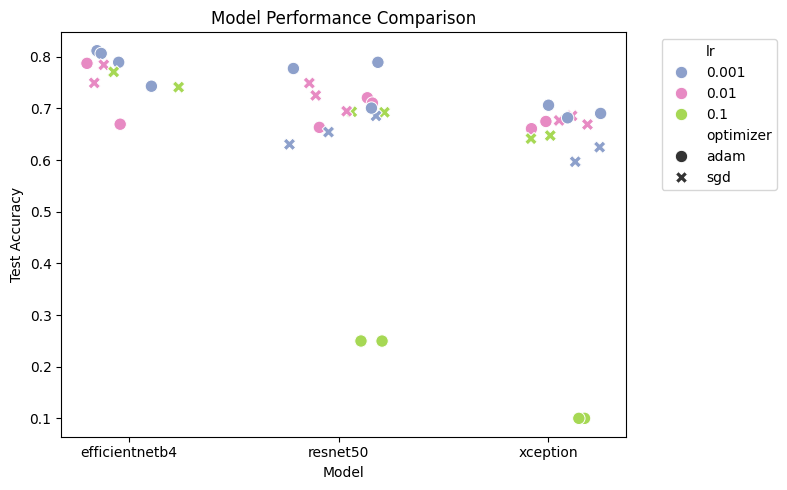

In [6]:
param_plot(df, param2="optimizer", param="lr")

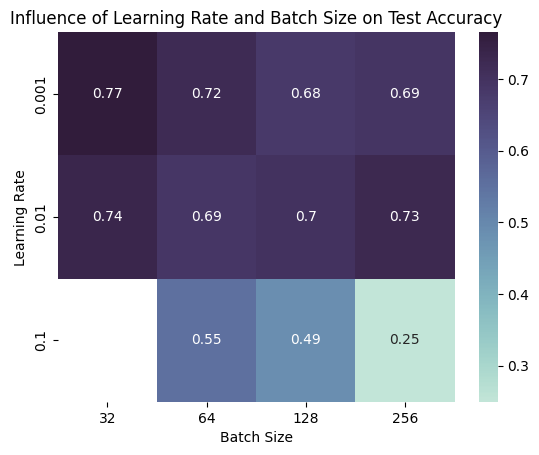

In [7]:
pivot = df.pivot_table(
    index="lr",
    columns="batch_size",
    values="val_accuracy",
    aggfunc="mean"
)
palette_cmap = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
sns.heatmap(pivot, annot=True, cmap=palette_cmap)
plt.title(f"Influence of Learning Rate and Batch Size on Test Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Learning Rate")
plt.show()

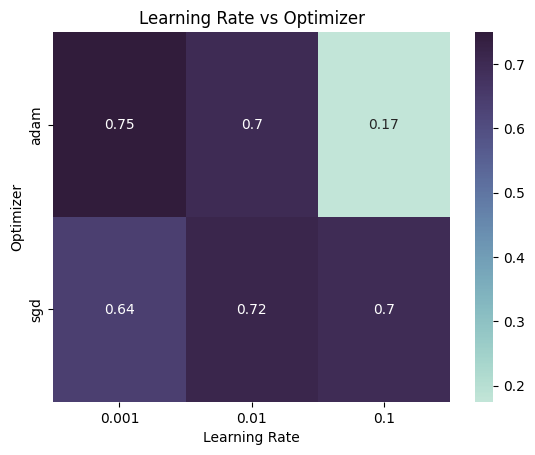

In [8]:
pivot = df.pivot_table(
    index="optimizer",
    columns="lr",
    values="val_accuracy",
    aggfunc="mean"
)
palette_cmap = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
sns.heatmap(pivot, annot=True, cmap=palette_cmap)
plt.title(f"Learning Rate vs Optimizer")
plt.xlabel("Learning Rate")
plt.ylabel("Optimizer")
plt.show()

/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/326935027.py:5: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(


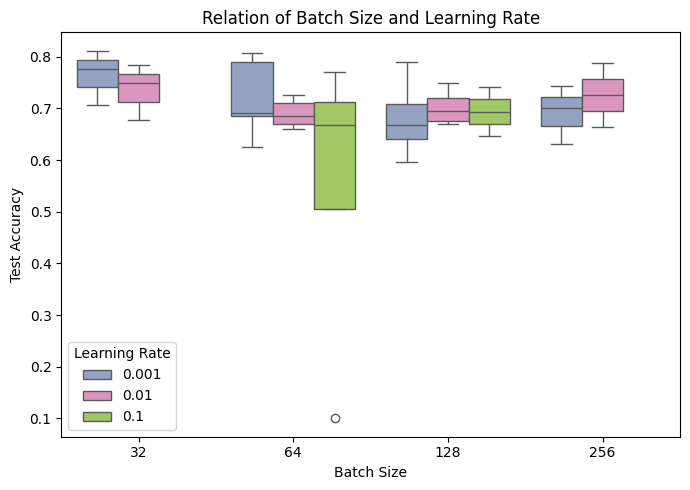

In [9]:
plt.figure(figsize=(7, 5))

df_filtered = df[df["num_epochs"] > 6]

sns.boxplot(
    data=df_filtered,
    x="batch_size",
    y="val_accuracy",
    # color=palette[2],
    hue="lr",
    palette=palette
)

plt.title("Relation of Batch Size and Learning Rate")
plt.ylabel("Test Accuracy")
plt.xlabel("Batch Size")
plt.legend(title="Learning Rate")
plt.tight_layout()
plt.show()

/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/2214755510.py:5: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(


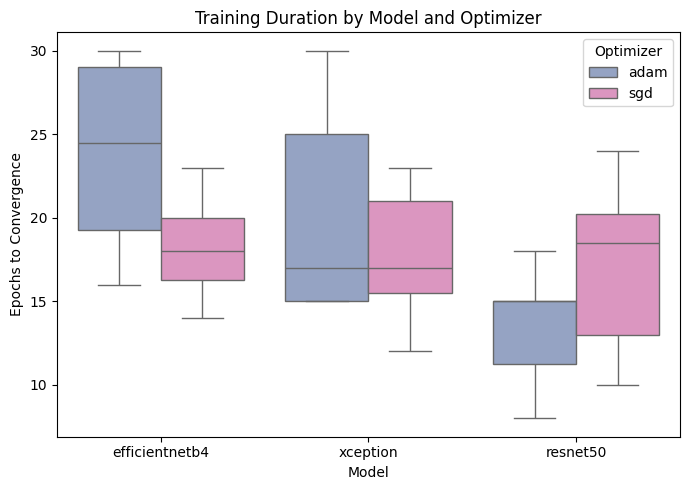

In [10]:
plt.figure(figsize=(7, 5))

df_filtered = df[df["num_epochs"] > 6]

sns.boxplot(
    data=df_filtered,
    x="model_name",
    y="num_epochs",
    # color=palette[2],
    hue="optimizer",
    palette=palette
)

plt.title("Training Duration by Model and Optimizer")
plt.ylabel("Epochs to Convergence")
plt.xlabel("Model")
plt.legend(title="Optimizer")
plt.tight_layout()
plt.show()

/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/3948136443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["efficiency"] = df["val_accuracy"] / df["num_epochs"]


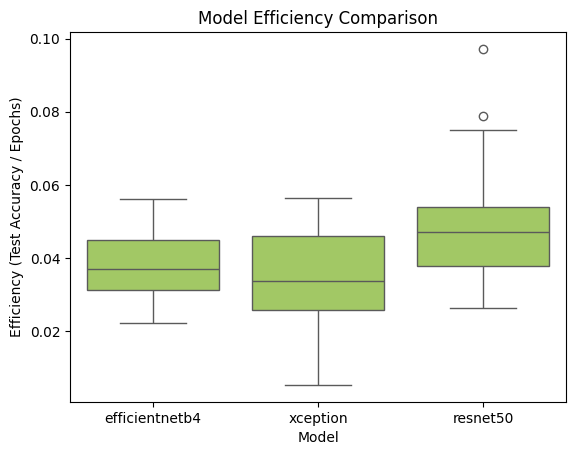

In [11]:
df["efficiency"] = df["val_accuracy"] / df["num_epochs"]

sns.boxplot(
    data=df,
    x="model_name",
    y="efficiency",
    color=palette[2]
)

plt.title("Model Efficiency Comparison")
plt.ylabel("Efficiency (Test Accuracy / Epochs)")
plt.xlabel("Model")
plt.show()

/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/83677643.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_epochs = df_epochs[~bad_row_2].copy()


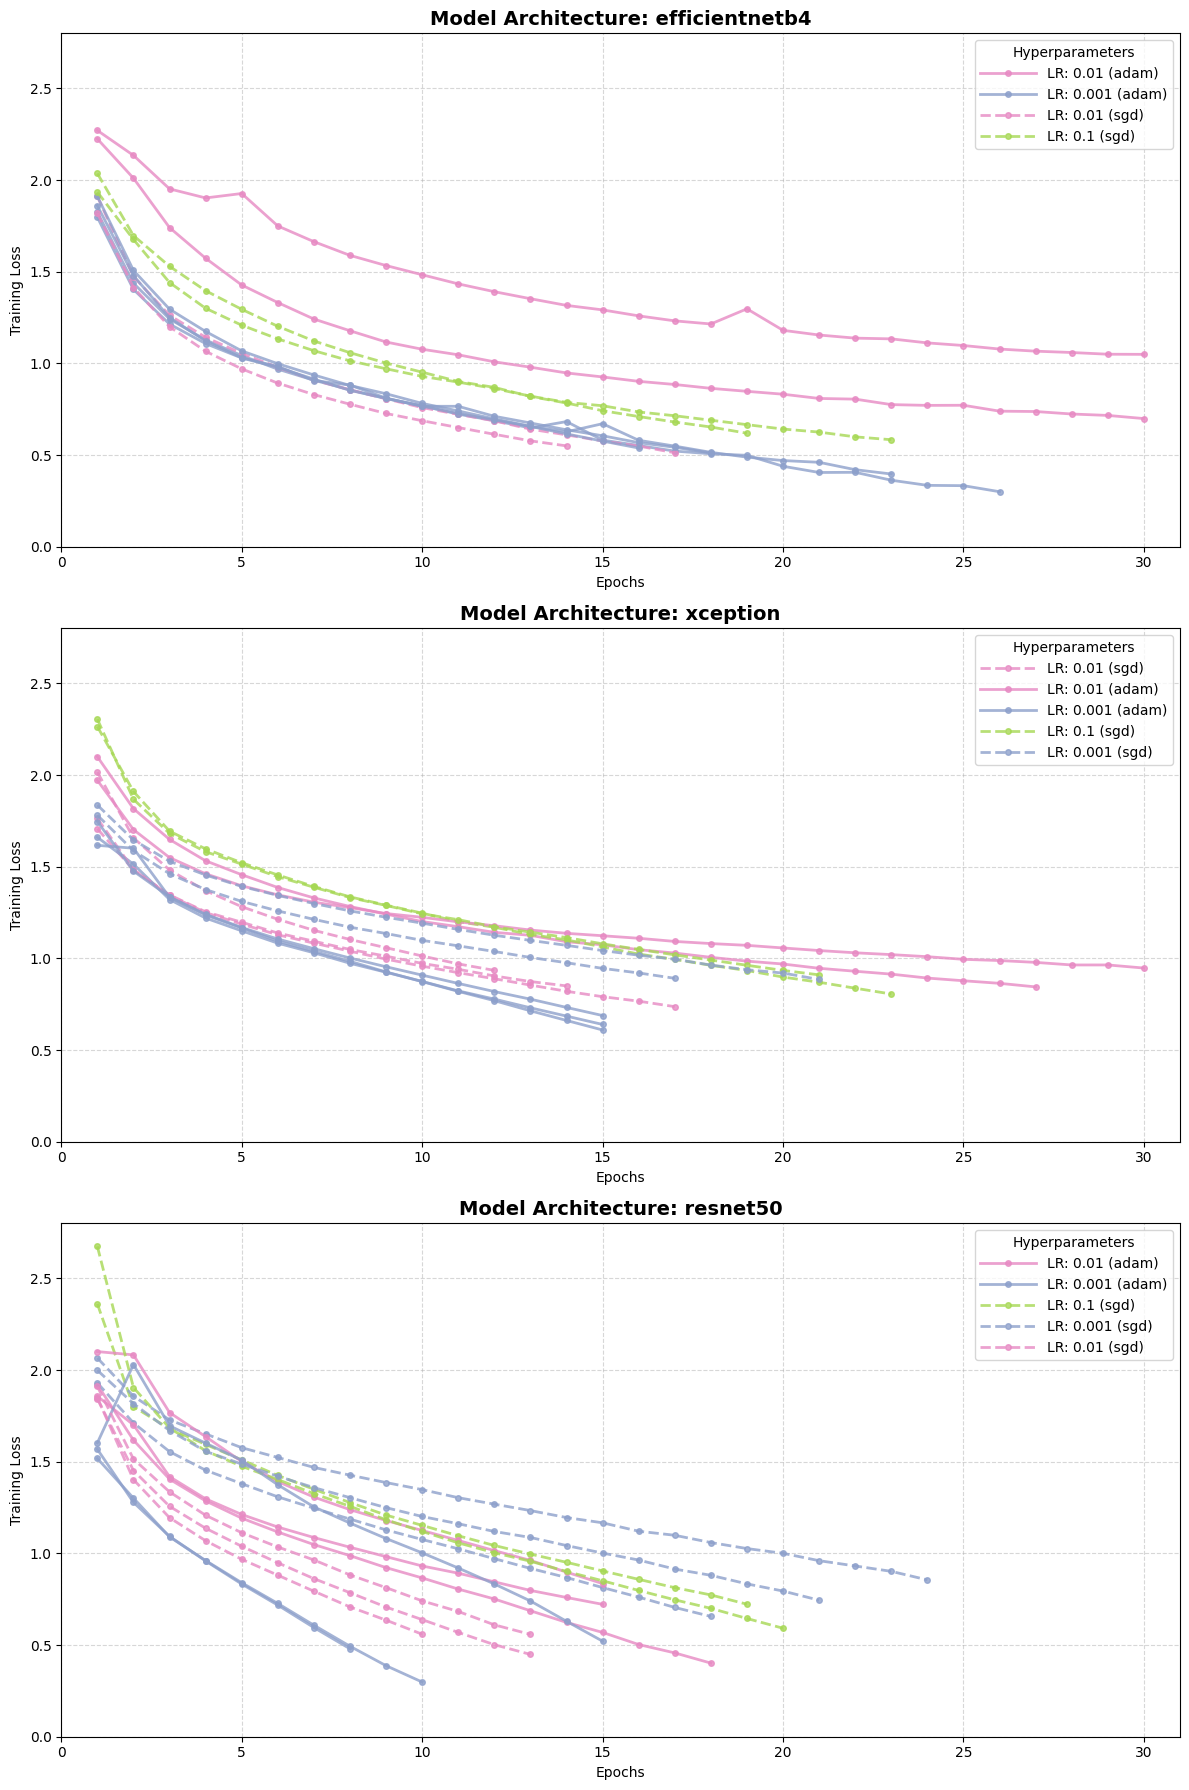

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

def safe_parse_history(val):
    if pd.isna(val):
        return None
    if isinstance(val, dict):
        return val
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return None

bad_row = (df["batch_size"].isin([256, 128])) & \
          (df["model_name"] == "resnet50") & \
          (df["optimizer"] == "adam") & \
          (df["lr"] == 0.1)

bad_row_2 = (df["model_name"] == "xception") & \
          (df["lr"] == 0.1) & \
            (df["optimizer"] == "adam")

df_epochs = df[~bad_row].copy()
df_epochs = df_epochs[~bad_row_2].copy()

df_epochs['history'] = df_epochs['history'].apply(safe_parse_history)
plot_df = df_epochs[df_epochs['history'].notna()].copy()

models = plot_df['model_name'].unique()
n_models = len(models)

fig, axes = plt.subplots(n_models, 1, figsize=(12, 6 * n_models), squeeze=False)

style_map = {'adam': '-', 'sgd': '--'}
unique_lrs = sorted(plot_df['lr'].unique())
lr_color_map = dict(zip(unique_lrs, palette[:len(unique_lrs)]))

for i, model in enumerate(models):
    ax = axes[i, 0]
    model_df = plot_df[plot_df['model_name'] == model]
    
    for _, row in model_df.iterrows():
        history = row['history']
        if 'epoch' in history and 'train_loss' in history:
            current_lr = row['lr']
            optimizer = row['optimizer']
            ax.plot(history['epoch'], history['train_loss'], 
                    label=f"LR: {current_lr} ({optimizer})", 
                    color=lr_color_map[current_lr],
                    linestyle=style_map.get(optimizer.lower(), '-'),
                    linewidth=2,
                    marker='o', 
                    markersize=4,
                    alpha=0.8)

    ax.set_title(f"Model Architecture: {model}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Training Loss")
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    
    ax.legend(by_label.values(), by_label.keys(), 
              title="Hyperparameters",
               handlelength=4)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0, 2.8)
    ax.set_xlim(0, 31)

plt.tight_layout()
plt.show()

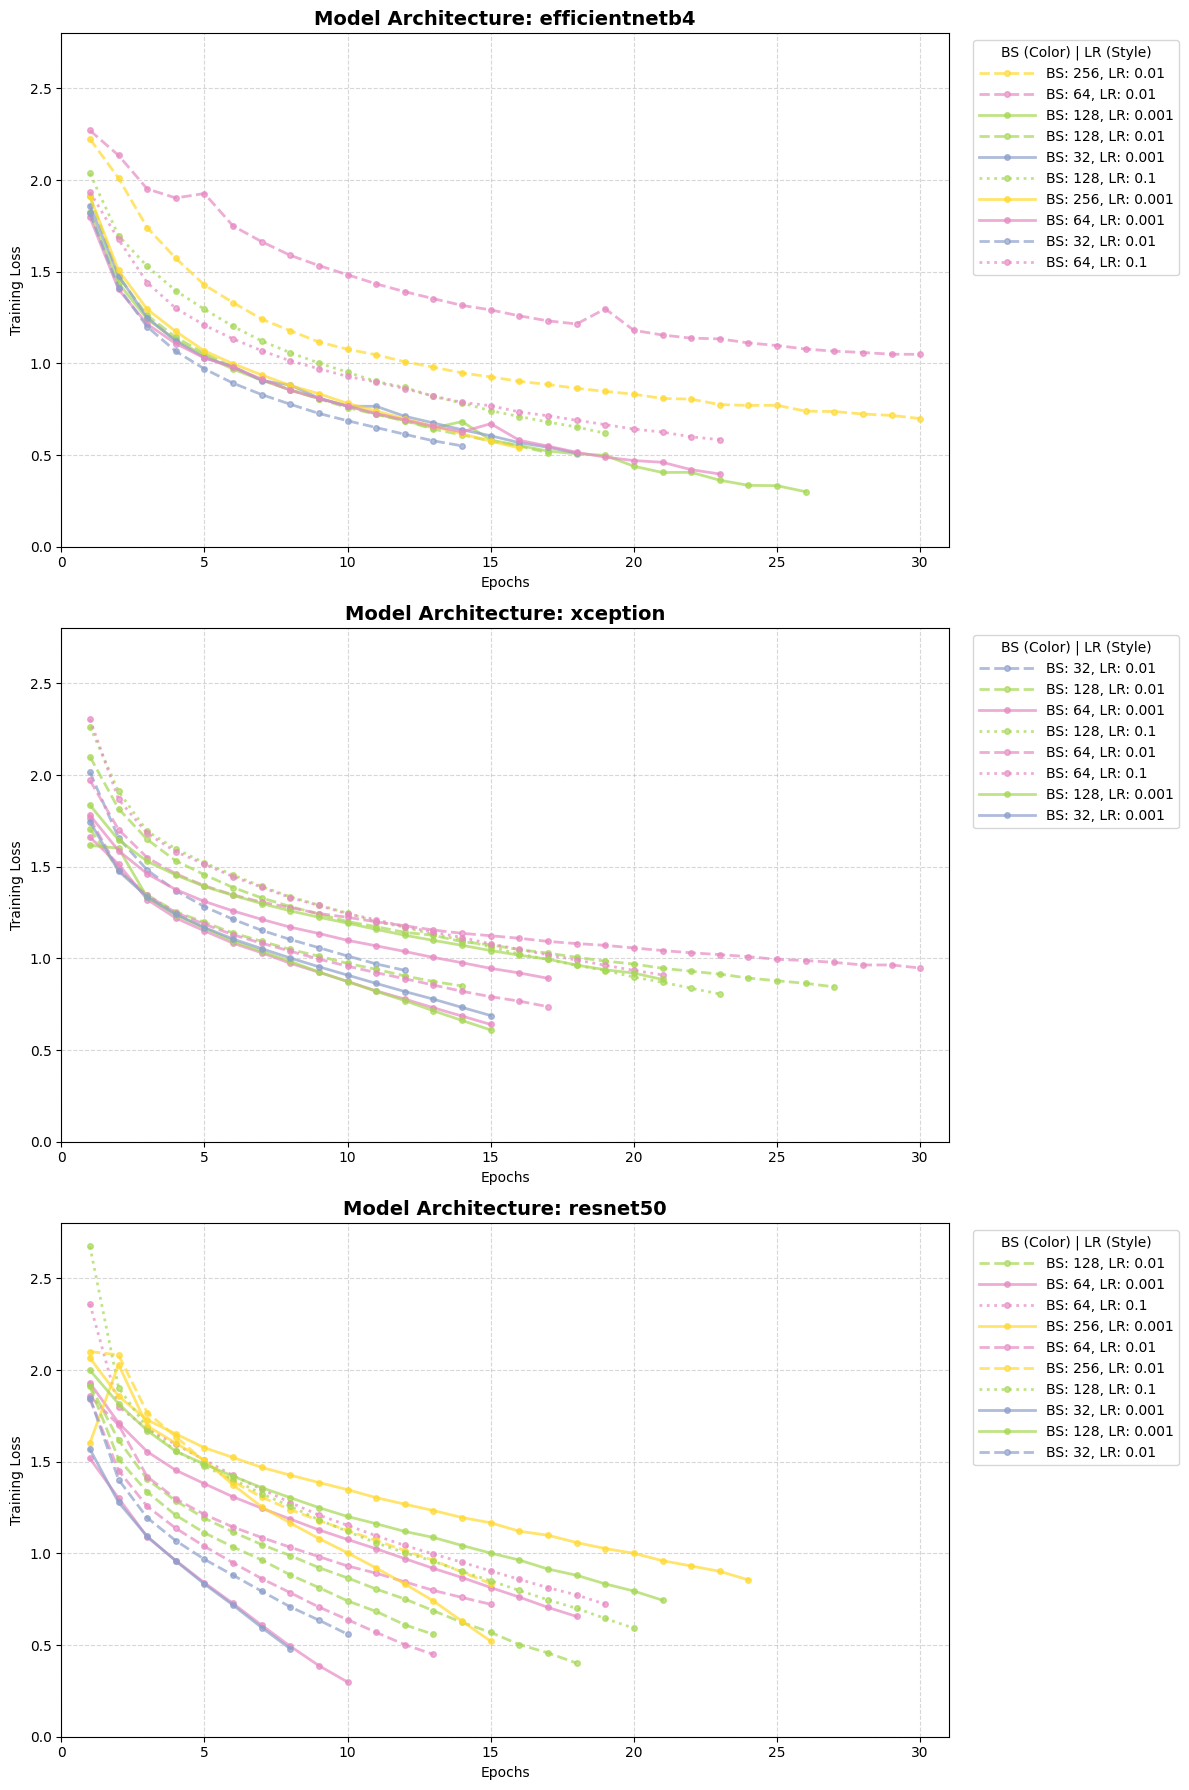

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

def safe_parse_history(val):
    if pd.isna(val):
        return None
    if isinstance(val, dict):
        return val
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return None

bad_row = (df["batch_size"].isin([256, 128])) & \
          (df["model_name"] == "resnet50") & \
          (df["optimizer"] == "adam") & \
          (df["lr"] == 0.1)

bad_row_2 = (df["model_name"] == "xception") & \
          (df["lr"] == 0.1) & \
          (df["optimizer"] == "adam")

df_epochs = df[~(bad_row | bad_row_2)].copy()
df_epochs['history'] = df_epochs['history'].apply(safe_parse_history)
plot_df = df_epochs[df_epochs['history'].notna()].copy()

models = plot_df['model_name'].unique()
n_models = len(models)

fig, axes = plt.subplots(n_models, 1, figsize=(12, 6 * n_models), squeeze=False)

unique_bs = sorted(plot_df['batch_size'].unique())
bs_color_map = dict(zip(unique_bs, palette[:len(unique_bs)]))

unique_lrs = sorted(plot_df['lr'].unique())
styles = ['-', '--', ':']
style_map = dict(zip(unique_lrs, styles[:len(unique_lrs)]))

for i, model in enumerate(models):
    ax = axes[i, 0]
    model_df = plot_df[plot_df['model_name'] == model]
    
    for _, row in model_df.iterrows():
        history = row['history']
        if 'epoch' in history and 'train_loss' in history:
            current_lr = row['lr']
            current_bs = row['batch_size']
            
            ax.plot(history['epoch'], history['train_loss'], 
                    label=f"BS: {current_bs}, LR: {current_lr}", 
                    color=bs_color_map[current_bs],
                    linestyle=style_map.get(current_lr, '-'),
                    linewidth=2,
                    marker='o', 
                    markersize=4,
                    alpha=0.7)

    ax.set_title(f"Model Architecture: {model}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Training Loss")
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    
    ax.legend(by_label.values(), by_label.keys(), 
              title="BS (Color) | LR (Style)",
              bbox_to_anchor=(1.02, 1), 
              loc='upper left',
              handlelength=4)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0, 2.8)
    ax.set_xlim(0, 31)

plt.tight_layout()
plt.show()

## PHASE 2

In [14]:
base_configs = [
    {'model_name': 'efficientnetb4', 'batch_size': 64, 'optimizer': 'adam', 'lr': 0.001},
    {'model_name': 'xception', 'batch_size': 32, 'optimizer': 'adam', 'lr': 0.001},
    {'model_name': 'resnet50', 'batch_size': 64, 'optimizer': 'adam', 'lr': 0.001}
]

mask = pd.Series([False] * len(df))
for config in base_configs:
    cond = (df_raw['model_name'] == config['model_name']) & \
           (df_raw['batch_size'] == config['batch_size']) & \
           (df_raw['optimizer'] == config['optimizer']) & \
           (df_raw['lr'] == config['lr'])
    mask = mask | cond

df_2 = df_raw[mask]

/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/2526549062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2['setup'] = df_2.apply(lambda r: f"{r['regularization']}+{r['dropout']}", axis=1)
/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/2526549062.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2['setup'] = df_2['setup'].replace({
/var/folders/fv/md92rv4d70b83bb1m1pbrps40000gn/T/ipykernel_65082/2526549062.py:15: UserWarning: The palette list has more values (

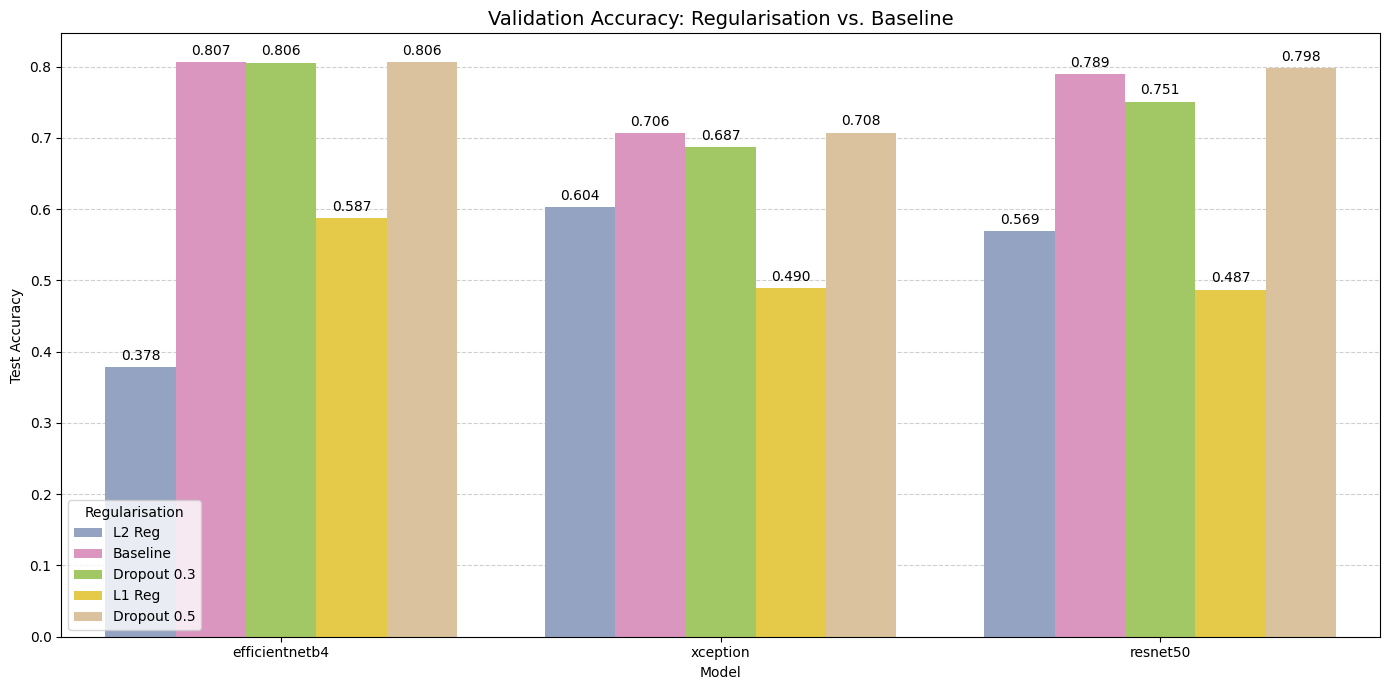

In [15]:
df_2['setup'] = df_2.apply(lambda r: f"{r['regularization']}+{r['dropout']}", axis=1)
df_2['setup'] = df_2['setup'].replace({
    'none+0.0': 'Baseline',
    'l1+0.0': 'L1 Reg',
    'l2+0.0': 'L2 Reg',
    'none+0.3': 'Dropout 0.3',
    'none+0.5': 'Dropout 0.5',
    'l1+0.3': 'L1 + Dropout 0.3',
    'l1+0.5': 'L1 + Dropout 0.5',
    'l2+0.3': 'L2 + Dropout 0.3',
    'l2+0.5': 'L2 + Dropout 0.5'
})
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=df_2,
    x='model_name',
    y='val_accuracy',
    hue='setup',
    palette=palette
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',     
        padding=3,
        fontsize=10
    )

ax.set_axisbelow(True)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title('Validation Accuracy: Regularisation vs. Baseline', fontsize=14)
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.legend(title='Regularisation', loc='lower left')

plt.tight_layout()
plt.show()

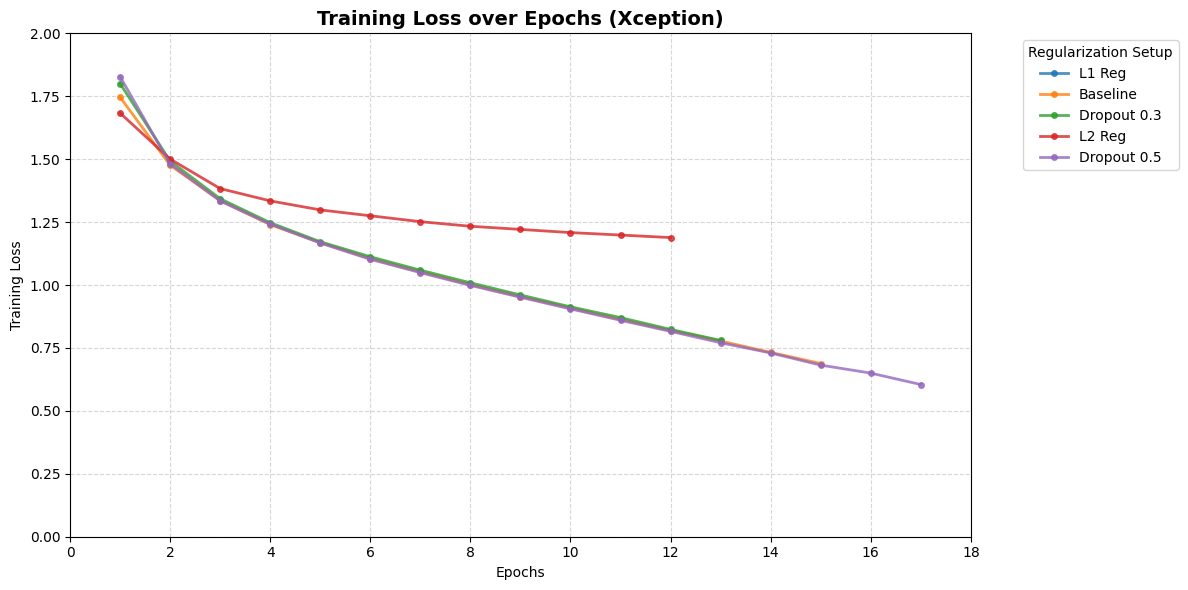

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

def safe_parse_history(val):
    if pd.isna(val):
        return None
    if isinstance(val, dict):
        return val
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return None


df_epochs = df_2.copy()
df_epochs['history'] = df_epochs['history'].apply(safe_parse_history)
plot_df = df_epochs[df_epochs['history'].notna()].copy()

plot_df = plot_df[plot_df['model_name'] == 'xception']

unique_setups = plot_df['setup'].unique()
palette = sns.color_palette("tab10", len(unique_setups))
setup_color_map = dict(zip(unique_setups, palette))

plt.figure(figsize=(12, 6))

for _, row in plot_df.iterrows():
    history = row['history']
    
    if 'epoch' in history and 'train_loss' in history:
        setup = row['setup']
        
        plt.plot(
            history['epoch'],
            history['train_loss'],
            label=setup,
            color=setup_color_map[setup],
            linewidth=2,
            marker='o',
            markersize=4,
            alpha=0.8
        )

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

plt.legend(
    by_label.values(),
    by_label.keys(),
    title="Regularization Setup",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("Training Loss over Epochs (Xception)", fontsize=14, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 2)
plt.xlim(0, 18)

plt.tight_layout()
plt.show()